# MACHINE LEARNING OPERATIONS :California Housing Price Prediction
ELIANA KARIUKI

10/03/2026

CS-DA03-26048

### **Introduction**
In this assignment, I built an end-to-end machine learning workflow
to predict housing prices using the California Housing dataset.
The focus is on applying key concepts covered in class: preprocessing,
cross-validation, hyperparameter tuning, pipeline construction,
and model deployment.

The California Housing dataset is a well-known regression dataset
containing information collected from the 1990 California census.
It is available directly through Scikit-learn and contains 8 features
such as median income, house age, and location coordinates, with the
target variable being the median house value in $100,000s.

**Objectives**
- Load and explore the California Housing dataset
- Apply preprocessing using ColumnTransformer
- Split the data into training and test sets (80/20)
- Build a KNeighborsRegressor model
- Tune hyperparameters using GridSearchCV with 5-fold cross-validation
- Evaluate the model using R² Score
- Save the trained pipeline using pickle

### Loading & exploring the California Housing dataset

importing neccesary libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

In [25]:
# Loading the dataset
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

print("Dataset shape:", df.shape)
print("\nFeature names:", housing.feature_names)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


EDA

In [26]:
# Dataset info and statistics
print("Dataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

Basic statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


- The dataset contains **20,640 samples and 9 columns** (8 features + 1 target)
- **No missing values** across all columns — no cleaning required
- All features are stored as float64
- The average median house value is **$207,000** (2.07 in $100,000s)
- House values range from **$15,000 to $500,000**

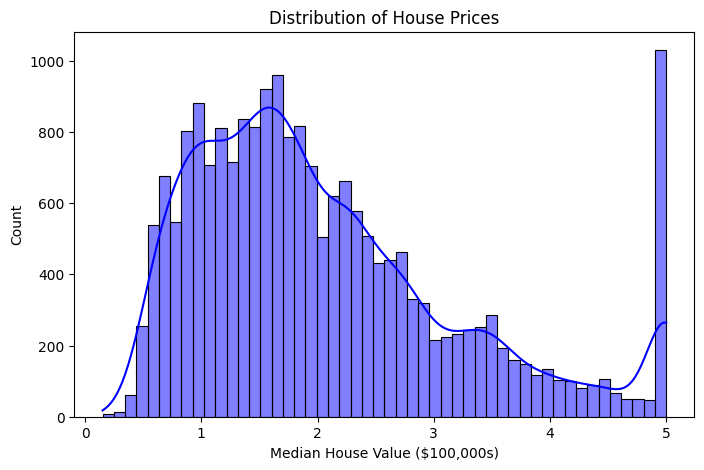

In [27]:
# Target distribution
plt.figure(figsize=(8,5))
sns.histplot(df['target'], bins=50, kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Count')
plt.show()


**Distribution of House Prices:**
The histogram shows that house prices are right-skewed, with most homes
valued between $100,000 and $300,000. There is a sharp spike at $500,000
indicating that many values were capped at that amount in the dataset.

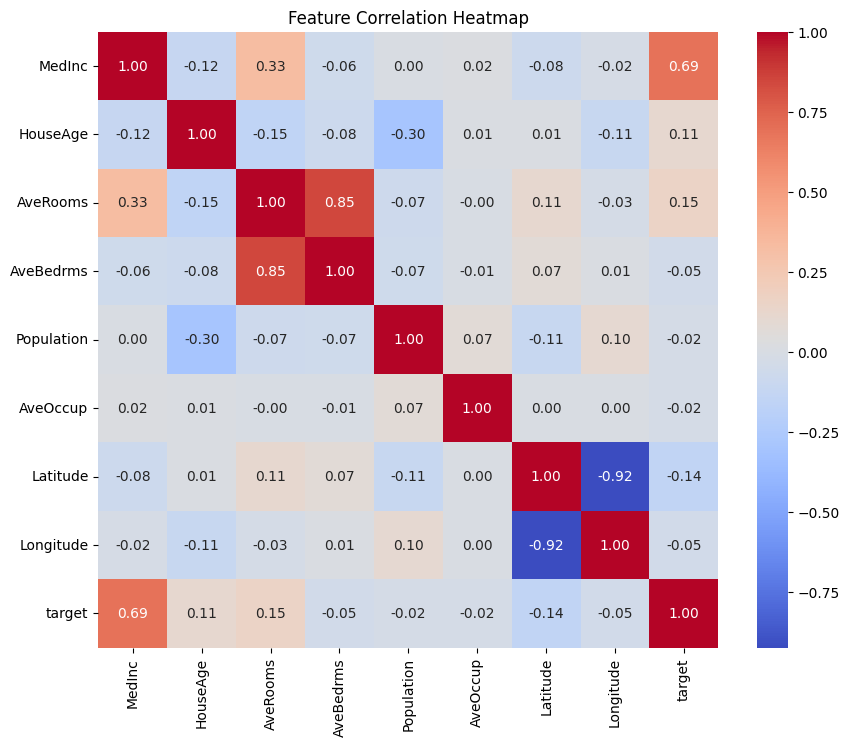

In [28]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


**Feature Correlation Heatmap:**
- **MedInc** has the strongest positive correlation with the target (0.69)
  — higher income areas have higher house values
- **Latitude** and **Longitude** show negative correlations with the target
- Most other features show weak correlations with the target

### Preprocessing and train test splitting

In [29]:
# Define features and target
X = df.drop('target', axis=1)
y = df['target']

# Apply ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), X.columns.tolist())
])

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 16512
Test samples: 4128


### Building the Pipeline with KNeighborsRegressor

In [30]:
# Build the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor())
])

# Fit the pipeline on training data
pipeline.fit(X_train, y_train)

# Quick evaluation before tuning
y_pred = pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R² Score (before tuning):", r2)

R² Score (before tuning): 0.6700101862970989


### Hyperparameter Tuning with GridSearchCV

In [31]:
# Define hyperparameters to tune
param_grid = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

# Apply GridSearchCV with 5-fold cross validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation R² Score:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}
Best Cross Validation R² Score: 0.731266870986164


**Hyperparameter Tuning Results**

GridSearchCV tried 16 combinations with 5-fold cross-validation (80 fits total).

**Best Parameters:**
- n_neighbors: 9
- weights: distance
- p: 1 (Manhattan distance)

**Best Cross Validation R² Score: 0.7313**

The best model uses 9 neighbors, weights predictions by distance,
and measures distance using the Manhattan method.

### Evaluating the Model

In [33]:
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

from sklearn.metrics import mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)
print("Test R² Score:", r2)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

Best Parameters: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}
Best CV R² Score: 0.731266870986164
Test R² Score: 0.72210916268423
Test MSE: 0.3641506481894662
Test RMSE: 0.6034489607162036


Model Evaluation Results

| Metric | Value |
|--------|-------|
| Best CV R² Score | 0.7313 |
| Test R² Score | 0.7221 |
| Test MSE | 0.3642 |
| Test RMSE | 0.6034 |

The tuned model explains 72.21% of the variation in house prices on
the test set. The RMSE of 0.60 means predictions are typically off
by $60,000 in house value.

### Saving the Trained Pipeline

In [34]:
# Save the trained pipeline using pickle
with open('california_housing_pipeline.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Pipeline saved successfully!")

Pipeline saved successfully!


I saved the trained pipeline using Python's pickle library as california_housing_pipeline.pkl. This allows the model to be reused for predictions at any time without having to retrain it from scratch, making it ready for deployment in a real world application.